In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("C:\\Users\\mimusaib\\Desktop\\Data_Science_Internship\\Week_4\\Dataset\\Mall_Customers2.csv")

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   City                    200 non-null    str  
 6   Customer_Level          200 non-null    str  
dtypes: int64(4), str(3)
memory usage: 11.1 KB


In [5]:
missing = df.isnull().sum()
missing

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
City                      0
Customer_Level            0
dtype: int64

In [6]:
X_raw = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [7]:
features = ['Age','Annual Income (k$)','Spending Score (1-100)']
X = df[features]

In [8]:
from sklearn.model_selection import train_test_split 
X_train , X_test = train_test_split(
    X,
    test_size = 0.3,
    random_state = 42
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(140, 3)
(60, 3)


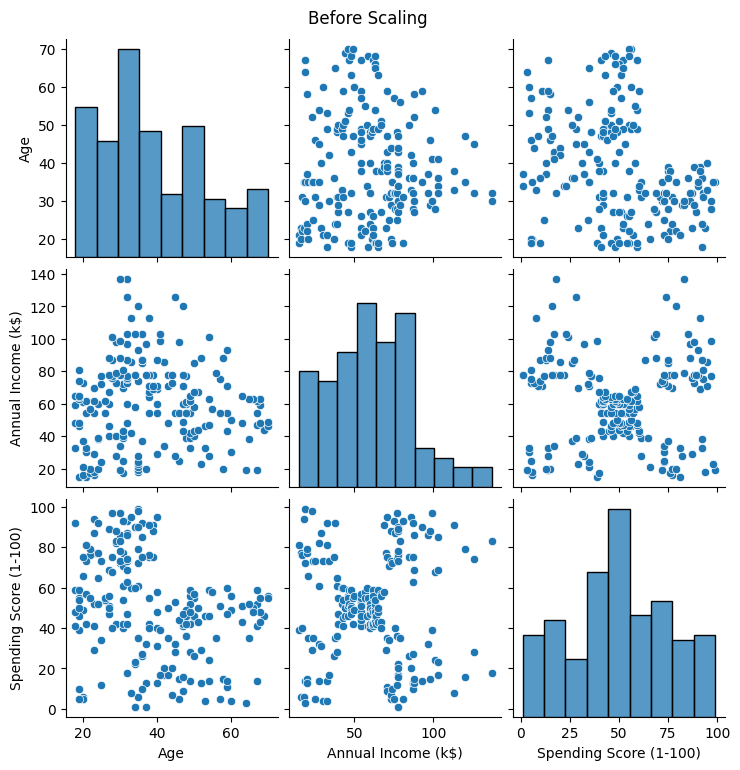

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)
plt.suptitle('Before Scaling ', y =1.02)
plt.show()

In [11]:
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,columns = features)

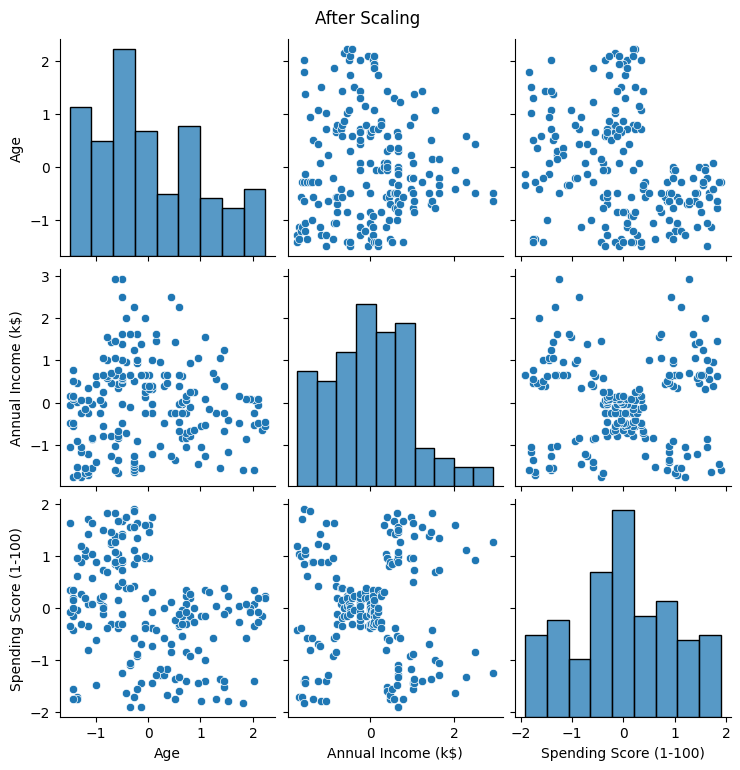

In [12]:
sns.pairplot(X_scaled)
plt.suptitle('After Scaling ', y =1.02)
plt.show()

In [13]:
from sklearn.cluster import  KMeans


In [14]:
k_means_raw =KMeans(n_clusters = 5, random_state = 42)
labels_raw = k_means_raw.fit_predict(X_raw)

inertia_raw = k_means_raw.inertia_

In [15]:
k_means_scaled =KMeans(n_clusters = 5, random_state = 42)
labels_scaled = k_means_scaled.fit_predict(X_scaled)

inertia_scaled = k_means_scaled.inertia_

In [16]:
print("inertia(Before Scaling):",inertia_raw)
print("inertia(After Scaling):",inertia_scaled)

inertia(Before Scaling): 97211.84353980479
inertia(After Scaling): 169.89149793438582


In [17]:
from sklearn.metrics import silhouette_score


In [18]:
silhouette_raw = silhouette_score(X_raw,labels_raw)
silhouette_scaled = silhouette_score(X_scaled,labels_scaled)

In [19]:
print("Silhouette Score(Before Scaling):",silhouette_raw)
print("Silhouette Score(After Scaling):",silhouette_scaled)

Silhouette Score(Before Scaling): 0.3575963460506624
Silhouette Score(After Scaling): 0.40846873777345605


In [20]:
df['Customer_Level']

0       Low
1      High
2       Low
3      High
4       Low
       ... 
195    High
196     Low
197    High
198     Low
199    High
Name: Customer_Level, Length: 200, dtype: str

In [21]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df['Customer_Level_encoded'] = oe.fit_transform(df[['Customer_Level']])
df['Customer_Level_encoded']

0      0.0
1      2.0
2      0.0
3      2.0
4      0.0
      ... 
195    2.0
196    0.0
197    2.0
198    0.0
199    2.0
Name: Customer_Level_encoded, Length: 200, dtype: float64

In [22]:
df['Gender']

0        Male
1        Male
2      Female
3      Female
4      Female
        ...  
195    Female
196    Female
197      Male
198      Male
199      Male
Name: Gender, Length: 200, dtype: str

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Gender_Encoded']

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender_Encoded, Length: 200, dtype: int64

In [24]:
df_encoded = pd.get_dummies(df,columns=['City'],drop_first=True)
df_encoded

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer_Level,Customer_Level_encoded,Gender_Encoded,City_Delhi,City_Mumbai
0,1,Male,19,15,39,Low,0.0,1,True,False
1,2,Male,21,15,81,High,2.0,1,False,True
2,3,Female,20,16,6,Low,0.0,0,True,False
3,4,Female,23,16,77,High,2.0,0,False,False
4,5,Female,31,17,40,Low,0.0,0,False,True
...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,High,2.0,0,True,False
196,197,Female,45,126,28,Low,0.0,0,False,True
197,198,Male,32,126,74,High,2.0,1,True,False
198,199,Male,32,137,18,Low,0.0,1,False,False


In [25]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),City,Customer_Level,Customer_Level_encoded,Gender_Encoded
0,1,Male,19,15,39,Delhi,Low,0.0,1
1,2,Male,21,15,81,Mumbai,High,2.0,1
2,3,Female,20,16,6,Delhi,Low,0.0,0
3,4,Female,23,16,77,Bangalore,High,2.0,0
4,5,Female,31,17,40,Mumbai,Low,0.0,0
